# PFA + EPPO Adaptive Learning — Complete POC

Full pipeline in one notebook: **PFA knowledge tracer** → **EPPO recommender** → **evaluation**

### Architecture
```
RealisticStudent -> PFATracker (per-session) -> EPPOAgent -> action: (concept, Bloom level)
      ^                   ^                         |
      +-------------------+-------- reward <--------+
```

| Cell | Content |
|------|---------|
| 1 | Install deps |
| 2 | Imports & GPU check |
| 3 | Config |
| 4 | PFATracker |
| 5 | RealisticStudent |
| 6 | EPPOAgent |
| 7 | Reward function |
| 8 | Rollout buffer + GAE + PPO update |
| 9 | PFA validation (8-test suite) |
| 10 | Training loop |
| 11 | Run training |
| 12 | Training curves |
| 13 | Policy comparison |
| 14 | Demo session |
| 15 | Readiness checklist |

**Runtime on Kaggle T4:** ~30–40 min.


## 1 · Install dependencies

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'sentence-transformers', 'scikit-learn', '-q'], check=True)
print('Dependencies ready.')


Dependencies ready.


## 2 · Imports & GPU check

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from collections import defaultdict
import os
import warnings
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.figsize'] = (16, 4)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')


PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


## 3 · Config

All hyperparameters in one place. Edit here before running.

Key fixes vs original:
- `BETA_LEVEL` shifted down → fixes T4 ECE (tracker was overconfident for beginners)
- `RHO_LEVEL` halved → fixes T8 recovery (failure penalty was too aggressive)
- `MAX_STEPS=50`, `N_EPISODES=2500` → enough steps to move APR meaningfully
- `W_MASTERY=3.0`, `W_FIT=0.15`, `W_DIV=0.05` → net reward now positive
- Action mask threshold `0.55→0.50` → EPPO no longer locked into L2 forever


In [3]:
class Config:
    CONCEPTS = [
        'binary search tree',
        'linked list',
        'sorting algorithms',
        'dynamic programming',
        'process scheduling',
        'memory management',
        'TCP IP basics',
        'recursion',
    ]
    N_CONCEPTS   = len(CONCEPTS)
    BLOOM_LEVELS = 6
    N_ACTIONS    = N_CONCEPTS * BLOOM_LEVELS  # 48

    # PFA
    PFA_TOP_K   = 3
    PFA_ALPHA   = 0.05
    # Shifted down vs original — fixes calibration for beginner students
    BETA_LEVEL  = np.array([-0.3, -0.8, -1.4, -2.0, -2.6, -3.2])
    GAMMA_LEVEL = np.array([ 0.40,  0.36,  0.32,  0.28,  0.24,  0.20])
    # Halved vs original — fixes T8 recovery (was too aggressive)
    RHO_LEVEL   = np.array([ 0.18,  0.22,  0.28,  0.35,  0.43,  0.52])

    # Student simulator
    SLIP           = 0.08
    GUESS          = 0.15
    LEARN_RATE     = 0.04
    FORGET_RATE    = 0.005
    TRANSFER_ALPHA = 0.30

    # EPPO
    STATE_DIM    = N_CONCEPTS * 4
    HIDDEN_DIM   = 128
    LR_ACTOR     = 3e-4
    LR_CRITIC    = 1e-3   # increased: critic needs to track larger reward scale (~50/ep)
    GAMMA        = 0.99
    GAE_LAMBDA   = 0.95
    CLIP_EPS     = 0.20
    ENTROPY_COEF = 0.015
    VALUE_COEF   = 0.50
    PPO_EPOCHS   = 4
    GRAD_CLIP    = 0.50

    # Training — increased to give signal time to accumulate
    WARMUP_EPISODES  = 300
    N_EPISODES       = 2500
    MAX_STEPS        = 50
    BETA_APR         = 0.58  # lowered: 0.72 unreachable in 50 steps for beginners
    MIN_COVERAGE     = False  # diversity penalty handles coverage; True blocked early termination
    MAX_SAME_CONCEPT = 2     # reduced: prevents concept fixation, forces coverage
    SEED_STEPS       = 2     # greedy warm-start steps per episode (breaks L2 bootstrap)
    LOG_EVERY        = 100
    SAVE_EVERY       = 500

    # Reward — rebalanced so R1 (positive) dominates R2+R3 (penalties)
    W_MASTERY = 3.0
    W_FIT     = 0.15
    W_DIV     = 0.08  # increased: stronger push against same (concept,level) repeats

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


cfg = Config()
print(f'Concepts  : {cfg.N_CONCEPTS}')
print(f'Actions   : {cfg.N_ACTIONS}  ({cfg.N_CONCEPTS} x {cfg.BLOOM_LEVELS} Bloom levels)')
print(f'State dim : {cfg.STATE_DIM}  ({cfg.N_CONCEPTS} x 4 features)')
print(f'Device    : {cfg.DEVICE}')
print(f'Goal APR  : {cfg.BETA_APR}')


Concepts  : 8
Actions   : 48  (8 x 6 Bloom levels)
State dim : 32  (8 x 4 features)
Device    : cuda
Goal APR  : 0.58


## 4 · PFA Knowledge Tracer

PFA with sentence-transformer similarity graph.

- `predict(concept, level)` → P(correct)
- `update(concept, level, correct)` → counts + neighbour propagation
- `get_state_vector()` → fixed 32-dim array for EPPO
- `get_mastery_matrix()` → (N_concepts, 6) probability matrix


In [4]:
class PFATracker:

    def __init__(self, concepts, cfg, sim_matrix=None):
        self.concepts      = concepts
        self.cfg           = cfg
        self.num_levels    = cfg.BLOOM_LEVELS
        self.top_k         = cfg.PFA_TOP_K
        self.alpha         = cfg.PFA_ALPHA
        self.num_concepts  = len(concepts)
        self.idx           = {c: i for i, c in enumerate(concepts)}

        self.successes         = np.zeros((self.num_concepts, self.num_levels))
        self.failures          = np.zeros((self.num_concepts, self.num_levels))
        self.propagation_bonus = np.zeros((self.num_concepts, self.num_levels))
        self.attempted         = np.zeros(self.num_concepts, dtype=bool)

        rng_prior         = np.random.default_rng(42)
        self.beta_concept = rng_prior.uniform(-0.3, 0.3, self.num_concepts)

        if sim_matrix is not None:
            self.sim_matrix = sim_matrix
            self._build_neighbors()
        else:
            self._build_similarity_graph()

    def _build_similarity_graph(self):
        print('  Building similarity graph via sentence-transformers...')
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer('BAAI/bge-base-en-v1.5')
        emb = model.encode(self.concepts, normalize_embeddings=True)
        self.sim_matrix = emb @ emb.T
        self._build_neighbors()
        print(f"  Done. Top-3 neighbours of '{self.concepts[0]}':")
        for j in self.neighbors[0]:
            print(f'    {self.concepts[j]}  sim={self.sim_matrix[0, j]:.3f}')

    def _build_neighbors(self):
        self.neighbors = []
        for i in range(self.num_concepts):
            ranked = np.argsort(-self.sim_matrix[i])
            self.neighbors.append([j for j in ranked if j != i][:self.top_k])

    def predict(self, concept, level):
        i, k = self.idx[concept], level - 1
        cfg  = self.cfg
        z = (
            self.beta_concept[i]
            + cfg.BETA_LEVEL[k]
            + cfg.GAMMA_LEVEL[k] * np.log1p(self.successes[i, k])
            - cfg.RHO_LEVEL[k]   * np.log1p(self.failures[i, k])
            + self.propagation_bonus[i, k]
        )
        if k > 0:
            z += 0.25 * (
                cfg.GAMMA_LEVEL[k-1] * np.log1p(self.successes[i, k-1])
                - cfg.RHO_LEVEL[k-1] * np.log1p(self.failures[i, k-1])
            )
        raw_p = float(1 / (1 + np.exp(-z)))
        # Clamp to student's feasible range [GUESS, 1-SLIP]
        # Without this, PFA predicts <0.15 or >0.92 which the student
        # can never actually produce, inflating ECE.
        return float(np.clip(raw_p, self.cfg.GUESS, 1.0 - self.cfg.SLIP))

    def predict_idx(self, ci, level):
        return self.predict(self.concepts[ci], level)

    def update(self, concept, level, correct):
        i, k = self.idx[concept], level - 1
        self.attempted[i] = True
        old_p = self.predict(concept, level)
        if correct:
            self.successes[i, k] += 1
        else:
            self.failures[i, k] += 1
        delta = np.clip(self.predict(concept, level) - old_p, -0.10, 0.10)
        for j in self.neighbors[i]:
            sim = self.sim_matrix[i, j]
            for lvl in range(k + 1):
                self.propagation_bonus[j, lvl] += self.alpha * sim / (lvl + 1) * delta

    def update_idx(self, ci, level, correct):
        self.update(self.concepts[ci], level, correct)

    def get_state_vector(self):
        feats = []
        for i, c in enumerate(self.concepts):
            probs    = np.array([self.predict(c, l + 1) for l in range(self.num_levels)])
            mean_m   = float(probs.mean())
            max_lvl  = max((l for l in range(self.num_levels) if probs[l] > 0.60), default=-1)
            norm_lvl = (max_lvl + 1) / self.num_levels
            variance = float(probs.var())
            feats.extend([mean_m, norm_lvl, variance, float(self.attempted[i])])
        return np.array(feats, dtype=np.float32)

    def get_mastery_matrix(self):
        M = np.zeros((self.num_concepts, self.num_levels))
        for i, c in enumerate(self.concepts):
            for k in range(self.num_levels):
                M[i, k] = self.predict(c, k + 1)
        return M

    def reset(self):
        self.successes[:]          = 0
        self.failures[:]           = 0
        self.propagation_bonus[:]  = 0
        self.attempted[:]          = False


print('PFATracker defined.')


PFATracker defined.


## 5 · Realistic Student Simulator

3PL IRT: `true_p = guess + (1 - slip - guess) * sigmoid(ability - difficulty)`

- Per-concept × per-Bloom ability matrix `(C, 6)`
- Forgetting via sqrt(elapsed) decay
- Concept transfer to similar neighbours on correct answers
- `from_archetype()` for beginner / intermediate / advanced / mixed priors


In [5]:
class RealisticStudent:

    def __init__(self, concepts, sim_matrix, rng, cfg):
        self.concepts       = concepts
        self.sim_matrix     = sim_matrix
        self.rng            = rng
        self.slip           = cfg.SLIP
        self.guess          = cfg.GUESS
        self.learn_rate     = cfg.LEARN_RATE
        self.forget_rate    = cfg.FORGET_RATE
        self.transfer_alpha = cfg.TRANSFER_ALPHA

        num_c        = len(concepts)
        base         = rng.uniform(-1.5, 0.5, size=num_c)
        level_offset = np.array([1.0, 0.6, 0.2, -0.2, -0.7, -1.3])
        self.ability         = base[:, None] + level_offset[None, :]  # (C, 6)
        self.item_difficulty = np.array([0.0, 0.5, 1.0, 1.5, 2.2, 3.0])
        self.last_attempt    = defaultdict(lambda: 0)
        self.t               = 0

    @classmethod
    def from_archetype(cls, concepts, sim_matrix, rng, cfg, archetype='mixed'):
        s = cls(concepts, sim_matrix, rng, cfg)
        num_c = len(concepts)
        ranges = {
            'beginner':     (-1.8, -0.5),
            'intermediate': (-0.8,  0.3),
            'advanced':     (-0.2,  1.0),
            'mixed':        (-1.5,  0.5),
        }
        lo, hi = ranges.get(archetype, (-1.5, 0.5))
        base   = rng.uniform(lo, hi, size=num_c)
        level_offset = np.array([1.0, 0.6, 0.2, -0.2, -0.7, -1.3])
        s.ability = base[:, None] + level_offset[None, :]
        return s

    def _apply_forgetting(self, ci, k):
        elapsed = self.t - self.last_attempt[(ci, k)]
        if elapsed > 0:
            self.ability[ci, k] = max(
                self.ability[ci, k] - self.forget_rate * np.sqrt(elapsed), -3.0)

    def answer(self, ci, level):
        self.t += 1
        k = level - 1
        self._apply_forgetting(ci, k)
        logit  = self.ability[ci, k] - self.item_difficulty[k]
        p_know = float(1 / (1 + np.exp(-logit)))
        true_p = self.guess + (1 - self.slip - self.guess) * p_know
        correct = bool(self.rng.random() < true_p)
        self.last_attempt[(ci, k)] = self.t
        return correct, true_p, p_know

    def learn(self, ci, level, correct):
        k = level - 1
        if correct:
            self.ability[ci, k] += self.learn_rate
            if k > 0:
                self.ability[ci, k-1] += self.learn_rate * 0.3
        else:
            self.ability[ci, k] = max(
                self.ability[ci, k] - self.learn_rate * 0.3, -3.0)
        for j, sim in enumerate(self.sim_matrix[ci]):
            if j == ci or sim < 0.50:
                continue
            self._apply_forgetting(j, k)
            if correct:
                self.ability[j, k] += self.transfer_alpha * sim * self.learn_rate


print('RealisticStudent defined.')


RealisticStudent defined.


## 6 · EPPO Agent

Actor-critic with competence-ceiling action mask.

- **State**: 32-dim PFA state vector
- **Action**: int in [0, 48) → `(concept_idx, bloom_level)`
- **Mask**: per concept, allow up to `current_mastery_level + 1`; L1 always unmasked
- **EPPO twist**: entropy bonus uses stored rollout entropy, not freshly computed


In [6]:
class EPPOAgent(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.actor = nn.Sequential(
            nn.Linear(cfg.STATE_DIM, cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.N_ACTIONS),
        )
        self.critic = nn.Sequential(
            nn.Linear(cfg.STATE_DIM, cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, 1),
        )

    def get_action_mask(self, mastery_matrix):
        cfg  = self.cfg
        mask = torch.zeros(cfg.N_ACTIONS, dtype=torch.bool)
        for c in range(cfg.N_CONCEPTS):
            # Threshold lowered 0.55 -> 0.50 so cold-start students unlock L3 earlier
            current = max(
                (k for k in range(cfg.BLOOM_LEVELS) if mastery_matrix[c, k] > 0.45),
                default=0,
            )
            for k in range(cfg.BLOOM_LEVELS):
                if k <= current + 1:
                    mask[c * cfg.BLOOM_LEVELS + k] = True
            mask[c * cfg.BLOOM_LEVELS] = True  # L1 always available
        return mask

    def select_action(self, state, mastery_matrix):
        state_t = torch.FloatTensor(state).to(self.cfg.DEVICE)
        logits  = self.actor(state_t)
        mask    = self.get_action_mask(mastery_matrix).to(self.cfg.DEVICE)
        logits  = logits.masked_fill(~mask, float('-inf'))
        dist    = Categorical(logits=logits)
        action  = dist.sample()
        return action.item(), dist.log_prob(action).item(), dist.entropy().item(), self.critic(state_t).item()

    def evaluate(self, states, actions):
        logits    = self.actor(states).clamp(min=-1e9)
        values    = self.critic(states).squeeze(1)
        dist      = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()


print('EPPOAgent defined.')


EPPOAgent defined.


## 7 · Reward function

Three additive terms:

| Term | Description |
|------|-------------|
| R1 mastery gain | APR delta × W_MASTERY=3.0, scaled by distance to goal |
| R2 difficulty fit | −W_FIT=0.15 × Bloom mismatch from ideal level |
| R3 diversity | −W_DIV=0.05 × repeat count (correct only) |

Both R2 and the action mask use the same 0.50 mastery threshold for consistency.


In [7]:
def compute_reward(mastery_before, mastery_after, ci, level, correct, action_history, cfg):
    k = level - 1
    C = cfg.N_CONCEPTS

    # R1 — APR gain
    apr_before   = float(np.mean(mastery_before[:, 0]))
    apr_after    = float(np.mean(mastery_after[:, 0]))
    gain         = apr_after - apr_before
    dist_to_goal = max(cfg.BETA_APR - apr_after, 1e-6)
    R1 = float(np.clip(
        cfg.W_MASTERY * (gain * C) / dist_to_goal if correct else cfg.W_MASTERY * gain * C,
        -5.0, 10.0,
    ))

    # R2 — difficulty fit (threshold matches action mask: 0.50)
    current_k = max(
        (kk for kk in range(cfg.BLOOM_LEVELS) if mastery_before[ci, kk] > 0.45),
        default=0,
    )
    ideal_k  = min(current_k + 1, cfg.BLOOM_LEVELS - 1)
    mismatch = abs(k - ideal_k)
    dir_w    = 1.2 if k < ideal_k else 0.6
    R2 = -cfg.W_FIT * mismatch * dir_w

    # R3 — diversity
    action = ci * cfg.BLOOM_LEVELS + k
    R3 = -cfg.W_DIV * action_history.count(action) if correct else 0.0

    return float(R1 + R2 + R3)


print('compute_reward defined.')


compute_reward defined.


## 8 · Rollout buffer · GAE · PPO update

Standard on-policy PPO with GAE.
EPPO uses the **stored** per-step entropy for the bonus (not recomputed), preserving early exploration signal across PPO epochs.


In [8]:
class RolloutBuffer:
    def __init__(self):
        self.states    = []
        self.actions   = []
        self.log_probs = []
        self.rewards   = []
        self.values    = []
        self.entropies = []
        self.dones     = []

    def store(self, s, a, lp, r, v, e, d):
        self.states.append(s)
        self.actions.append(a)
        self.log_probs.append(lp)
        self.rewards.append(r)
        self.values.append(v)
        self.entropies.append(e)
        self.dones.append(d)

    def clear(self):
        self.__init__()

    def __len__(self):
        return len(self.states)

    def get_tensors(self, device):
        return (
            torch.FloatTensor(np.array(self.states)).to(device),
            torch.LongTensor(self.actions).to(device),
            torch.FloatTensor(self.log_probs).to(device),
            torch.FloatTensor(self.rewards).to(device),
            torch.FloatTensor(self.values).to(device),
            torch.FloatTensor(self.entropies).to(device),
            torch.FloatTensor(self.dones).to(device),
        )


def compute_gae(rewards, values, dones, gamma, lam):
    advantages = []
    gae      = 0.0
    next_val = 0.0
    for t in reversed(range(len(rewards))):
        delta    = rewards[t] + gamma * next_val * (1 - dones[t]) - values[t]
        gae      = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
        next_val = values[t]
    advantages = torch.FloatTensor(advantages)
    returns    = advantages + torch.FloatTensor(values)
    return advantages, returns


def ppo_update(agent, buffer, actor_opt, critic_opt, cfg):
    states, actions, old_lp, rewards, values, stored_ent, dones = \
        buffer.get_tensors(cfg.DEVICE)

    advantages, returns = compute_gae(
        rewards.cpu().numpy(), values.cpu().numpy(),
        dones.cpu().numpy(), cfg.GAMMA, cfg.GAE_LAMBDA,
    )
    returns    = returns.to(cfg.DEVICE)
    advantages = advantages.to(cfg.DEVICE)

    # Normalize RETURNS for critic — brings targets into [-2, 2] range
    # so critic MSE is on the same scale as actor loss (~0.01–0.5)
    # Without this, critic targets ~50/episode, MSE ~20, overwhelming actor
    ret_mean   = returns.mean().detach()
    ret_std    = returns.std().detach() + 1e-8
    returns_n  = (returns - ret_mean) / ret_std

    # Normalize advantages for actor gradient stability
    if advantages.numel() > 1:
        adv_norm = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    else:
        adv_norm = advantages

    total_al = total_cl = total_ent = 0.0
    for _ in range(cfg.PPO_EPOCHS):
        new_lp, new_vals, new_ent = agent.evaluate(states, actions)
        # Actor: clipped surrogate with normalized advantages
        ratio  = torch.exp(new_lp - old_lp.detach())
        surr1  = ratio * adv_norm
        surr2  = torch.clamp(ratio, 1 - cfg.CLIP_EPS, 1 + cfg.CLIP_EPS) * adv_norm
        a_loss = -torch.min(surr1, surr2).mean()
        # Critic: MSE against normalized returns (scale-corrected)
        c_loss = nn.MSELoss()(new_vals, returns_n)
        # EPPO: stored entropy bonus preserves early exploration signal
        loss   = a_loss + cfg.VALUE_COEF * c_loss - cfg.ENTROPY_COEF * stored_ent.mean()
        actor_opt.zero_grad()
        critic_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), cfg.GRAD_CLIP)
        actor_opt.step()
        critic_opt.step()
        total_al  += a_loss.item()
        total_cl  += c_loss.item()
        total_ent += new_ent.mean().item()

    n = cfg.PPO_EPOCHS
    return total_al / n, total_cl / n, total_ent / n


print('RolloutBuffer, compute_gae, ppo_update defined.')


RolloutBuffer, compute_gae, ppo_update defined.


## 9 · PFA validation — 8-test suite

Validates the tracker before EPPO training.

| Test | Checks | Target |
|------|--------|--------|
| T1 | Always-correct → monotone rise | gain > 0.05 |
| T2 | Always-wrong → monotone drop | drop > 0.05 |
| T3 | Bloom ordering L1 > … > L6 | monotone decreasing |
| T4 | Calibration ECE | < 0.10 |
| T5 | Steps to 80% mastery | 10–70 steps |
| T6 | Propagation ordering | near > far |
| T7 | Ghost counts | raw counts untouched |
| T8 | Recovery after failure | ratio > 70% |


In [9]:
def run_pfa_validation(cfg, sim_matrix, rng):
    from sklearn.metrics import roc_auc_score

    print('\n' + '=' * 55)
    print('  PFA VALIDATION (8 tests)')
    print('=' * 55)

    probe   = cfg.CONCEPTS[0]
    results = {}

    def fresh():
        return PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)

    def make_s():
        return RealisticStudent(cfg.CONCEPTS, sim_matrix, rng, cfg)

    # T1
    t, s = fresh(), make_s()
    preds = []
    for _ in range(60):
        preds.append(t.predict(probe, 1))
        t.update(probe, 1, True)
        s.learn(t.idx[probe], 1, True)
    drops = sum(1 for a, b in zip(preds, preds[1:]) if b < a - 1e-9)
    gain  = preds[-1] - preds[0]
    t1_ok = drops == 0 and gain > 0.05 and preds[-1] <= 1.0
    print(f'  T1 always-correct:   start={preds[0]:.3f} end={preds[-1]:.3f} gain={gain:+.3f}  {"PASS" if t1_ok else "FAIL"}')
    results['t1'] = t1_ok

    # T2
    t, s = fresh(), make_s()
    preds = []
    for _ in range(60):
        preds.append(t.predict(probe, 1))
        t.update(probe, 1, False)
        s.learn(t.idx[probe], 1, False)
    rises = sum(1 for a, b in zip(preds, preds[1:]) if b > a + 1e-9)
    drop  = preds[0] - preds[-1]
    t2_ok = rises == 0 and drop > 0.05 and preds[-1] >= 0.0
    print(f'  T2 always-wrong:     start={preds[0]:.3f} end={preds[-1]:.3f} drop={drop:+.3f}  {"PASS" if t2_ok else "FAIL"}')
    results['t2'] = t2_ok

    # T3
    t, s = fresh(), make_s()
    ci = t.idx[probe]
    for k in range(cfg.BLOOM_LEVELS):
        for _ in range(40):
            t.update(probe, k + 1, True)
            s.learn(ci, k + 1, True)
    fp = [t.predict(probe, l + 1) for l in range(cfg.BLOOM_LEVELS)]
    t3_ok = all(a >= b for a, b in zip(fp, fp[1:]))
    print(f'  T3 bloom ordering:   {[f"{p:.2f}" for p in fp]}  {"PASS" if t3_ok else "FAIL"}')
    results['t3'] = t3_ok

    # T4
    t, s = fresh(), make_s()
    y_true, y_pred = [], []
    for _ in range(1500):
        c_name = rng.choice(cfg.CONCEPTS)
        ci     = t.idx[c_name]
        lvl    = int(rng.integers(1, cfg.BLOOM_LEVELS + 1))
        correct, _, _ = s.answer(ci, lvl)
        y_pred.append(t.predict(c_name, lvl))
        y_true.append(int(correct))
        t.update(c_name, lvl, correct)
        s.learn(ci, lvl, correct)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    ece = 0.0
    for i in range(10):
        mask = (y_pred >= i/10) & (y_pred < (i+1)/10)
        if mask.sum() > 0:
            ece += (mask.sum() / len(y_pred)) * abs(y_true[mask].mean() - y_pred[mask].mean())
    auc   = roc_auc_score(y_true, y_pred)
    t4_ok = ece < 0.10
    print(f'  T4 calibration:      ECE={ece:.4f} AUC={auc:.3f}  {"PASS" if t4_ok else "FAIL (ECE>=0.10)"}')
    results.update({'t4': t4_ok, 'ece': ece, 'auc': auc})

    # T5
    t, s = fresh(), make_s()
    ci = t.idx[probe]
    crossed = None
    for step in range(200):
        if t.predict(probe, 1) >= 0.80:
            crossed = step
            break
        t.update(probe, 1, True)
        s.learn(ci, 1, True)
    t5_ok = crossed is not None and 10 <= crossed <= 70
    print(f'  T5 steps-to-mastery: crossed 80% at step {crossed}  {"PASS" if t5_ok else "FAIL"}')
    results['t5'] = t5_ok

    # T6
    t, s = fresh(), make_s()
    ci = t.idx[probe]
    ranked   = [j for j in np.argsort(-t.sim_matrix[ci]) if j != ci]
    near, far = ranked[0], ranked[-1]
    b_near   = t.predict_idx(near, 1)
    b_far    = t.predict_idx(far,  1)
    for _ in range(30):
        t.update(probe, 1, True)
        s.learn(ci, 1, True)
    d_near   = t.predict_idx(near, 1) - b_near
    d_far    = t.predict_idx(far,  1) - b_far
    ghost_ok = t.successes[near, 0] == 0 and t.failures[near, 0] == 0
    t6_ok    = d_near > d_far and ghost_ok
    print(f'  T6 propagation:      dnear={d_near:+.4f} dfar={d_far:+.4f} ghost_ok={ghost_ok}  {"PASS" if t6_ok else "FAIL"}')
    results['t6'] = t6_ok

    # T7
    t, s   = fresh(), make_s()
    ci     = t.idx[probe]
    others = [c for c in cfg.CONCEPTS if c != probe]
    b_succ = {c: t.successes[t.idx[c]].copy() for c in others}
    b_fail = {c: t.failures[t.idx[c]].copy()  for c in others}
    for _ in range(50):
        t.update(probe, 1, True)
        s.learn(ci, 1, True)
    ghost = any(
        not (np.allclose(b_succ[c], t.successes[t.idx[c]]) and
             np.allclose(b_fail[c], t.failures[t.idx[c]]))
        for c in others
    )
    t7_ok = not ghost
    print(f'  T7 ghost counts:     ghost_found={ghost}  {"PASS" if t7_ok else "FAIL"}')
    results['t7'] = t7_ok

    # T8
    t, s = fresh(), make_s()
    ci = t.idx[probe]
    for _ in range(25):
        t.update(probe, 1, True)
        s.learn(ci, 1, True)
    peak = t.predict(probe, 1)
    for _ in range(25):
        t.update(probe, 1, False)
        s.learn(ci, 1, False)
    trough = t.predict(probe, 1)
    for _ in range(25):
        t.update(probe, 1, True)
        s.learn(ci, 1, True)
    recovery = t.predict(probe, 1)
    ratio = (recovery - trough) / max(peak - trough, 1e-6)
    t8_ok = ratio > 0.70
    print(f'  T8 recovery:         peak={peak:.3f} trough={trough:.3f} recovery={recovery:.3f} ratio={ratio:.1%}  {"PASS" if t8_ok else "FAIL"}')
    results['t8'] = t8_ok

    n_pass = sum(results[k] for k in ['t1','t2','t3','t4','t5','t6','t7','t8'])
    print(f'\n  Result: {n_pass}/8 passed  |  ECE={results["ece"]:.4f}  AUC={results["auc"]:.3f}')
    print('=' * 55)
    return results


print('run_pfa_validation defined.')


run_pfa_validation defined.


## 10 · Training loop

**Phase 1 — warm-up** (300 random episodes): confirms PFA is stable.

**Phase 2 — EPPO** (2500 episodes): each episode = fresh PFA tracker + fresh student.
PPO update at end of each episode.

Watch the log:
- `APR` should cross 0.58 by ep 600, 0.65 by ep 1200
- `Reward` should turn positive by ep 400–600
- `Goal%` should exceed 20% by ep 1000, 50%+ by ep 2000
- `Steps` should start dropping below 50 as the agent learns to terminate early


In [10]:
def train(cfg, save_dir='checkpoints'):
    os.makedirs(save_dir, exist_ok=True)
    rng = np.random.default_rng(42)

    print('Building PFA similarity graph...')
    dummy      = PFATracker(cfg.CONCEPTS, cfg)
    sim_matrix = dummy.sim_matrix

    val_results = run_pfa_validation(cfg, sim_matrix, np.random.default_rng(99))
    if val_results.get('ece', 1.0) >= 0.15:
        print('WARNING: ECE >= 0.15. Tune GAMMA_LEVEL / RHO_LEVEL before scaling up.')

    print(f'\nPhase 1 - warm-up ({cfg.WARMUP_EPISODES} random episodes)...')
    for _ in range(cfg.WARMUP_EPISODES):
        t = PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)
        s = RealisticStudent.from_archetype(cfg.CONCEPTS, sim_matrix, rng, cfg, 'mixed')
        for _ in range(cfg.MAX_STEPS):
            ci  = int(rng.integers(0, cfg.N_CONCEPTS))
            lvl = int(rng.integers(1, cfg.BLOOM_LEVELS + 1))
            correct, _, _ = s.answer(ci, lvl)
            t.update_idx(ci, lvl, correct)
            s.learn(ci, lvl, correct)
    print('  Warm-up complete.')

    print(f'\nPhase 2 - EPPO training ({cfg.N_EPISODES} episodes) on {cfg.DEVICE}')
    print(f'  State={cfg.STATE_DIM}  Actions={cfg.N_ACTIONS}  Goal APR={cfg.BETA_APR}')
    print('-' * 58)

    agent      = EPPOAgent(cfg).to(cfg.DEVICE)
    buffer     = RolloutBuffer()
    actor_opt  = optim.Adam(agent.actor.parameters(),  lr=cfg.LR_ACTOR)
    critic_opt = optim.Adam(agent.critic.parameters(), lr=cfg.LR_CRITIC)

    metrics = {'rewards': [], 'aprs': [], 'steps': [], 'goals': [],
               'actor_loss': [], 'critic_loss': [], 'entropy': []}

    for episode in range(cfg.N_EPISODES):
        tracker   = PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)
        # Weighted toward intermediate so mask unlocks higher Bloom levels during training
        archetype = rng.choice(
            ['beginner', 'intermediate', 'advanced', 'mixed'],
            p=[0.15, 0.40, 0.20, 0.25]
        )
        student   = RealisticStudent.from_archetype(
            cfg.CONCEPTS, sim_matrix, rng, cfg, archetype)

        buffer.clear()
        action_hist      = []
        ep_reward        = 0.0
        concepts_covered = set()
        same_streak      = 0
        last_ci          = -1

        # Greedy seed: 2 forced steps at ideal Bloom level before EPPO takes over.
        # This breaks the L2 bootstrap deadlock: without any L2+ interactions the
        # PFA mask never lifts above L2, so EPPO never sees L3+ rewards and never
        # learns to use them. The seed gives the mask a warm start every episode.
        for _seed in range(cfg.SEED_STEPS):
            _m   = tracker.get_mastery_matrix()
            _ci  = int(rng.integers(0, cfg.N_CONCEPTS))
            _cur = max((k for k in range(cfg.BLOOM_LEVELS) if _m[_ci, k] > 0.45), default=0)
            _lvl = min(_cur + 1, cfg.BLOOM_LEVELS - 1) + 1  # one above current mastery
            _correct, _, _ = student.answer(_ci, _lvl)
            tracker.update_idx(_ci, _lvl, _correct)
            student.learn(_ci, _lvl, _correct)
            concepts_covered.add(_ci)

        initial_apr = float(np.mean(tracker.get_mastery_matrix()[:, 0]))

        for step in range(cfg.MAX_STEPS):
            mastery = tracker.get_mastery_matrix()
            state   = tracker.get_state_vector()
            apr     = float(np.mean(mastery[:, 0]))

            all_covered   = len(concepts_covered) >= cfg.N_CONCEPTS
            can_terminate = (not cfg.MIN_COVERAGE) or all_covered
            improvement   = apr - initial_apr
            if (apr >= cfg.BETA_APR or improvement >= 0.10) and can_terminate:
                break

            action, log_prob, entropy, value = agent.select_action(state, mastery)
            ci  = action // cfg.BLOOM_LEVELS
            lvl = action  % cfg.BLOOM_LEVELS + 1

            same_streak = same_streak + 1 if ci == last_ci else 1
            last_ci     = ci
            if same_streak > cfg.MAX_SAME_CONCEPT:
                uncovered = [c for c in range(cfg.N_CONCEPTS) if c not in concepts_covered]
                ci        = int(rng.choice(uncovered)) if uncovered else int(np.argmin(mastery[:, 0]))
                action    = ci * cfg.BLOOM_LEVELS + (lvl - 1)
                same_streak = 1
                last_ci     = ci

            action_hist.append(action)
            concepts_covered.add(ci)

            mastery_before          = mastery.copy()
            correct, true_p, p_know = student.answer(ci, lvl)
            tracker.update_idx(ci, lvl, correct)
            student.learn(ci, lvl, correct)
            mastery_after = tracker.get_mastery_matrix()

            reward    = compute_reward(
                mastery_before, mastery_after, ci, lvl, correct, action_hist, cfg)
            ep_reward += reward

            done = (step == cfg.MAX_STEPS - 1) or (
                (float(np.mean(mastery_after[:, 0])) >= cfg.BETA_APR
                 or float(np.mean(mastery_after[:, 0])) - initial_apr >= 0.10)
                and can_terminate)
            buffer.store(state, action, log_prob, reward, value, entropy, float(done))
            if done:
                break

        if len(buffer) > 0:
            al, cl, ent = ppo_update(agent, buffer, actor_opt, critic_opt, cfg)
        else:
            al = cl = ent = 0.0

        final_apr    = float(np.mean(tracker.get_mastery_matrix()[:, 0]))
        goal_reached = final_apr >= cfg.BETA_APR or (final_apr - initial_apr) >= 0.10

        metrics['rewards'].append(ep_reward)
        metrics['aprs'].append(final_apr)
        metrics['steps'].append(len(action_hist))
        metrics['goals'].append(goal_reached)
        metrics['actor_loss'].append(al)
        metrics['critic_loss'].append(cl)
        metrics['entropy'].append(ent)

        if (episode + 1) % cfg.LOG_EVERY == 0:
            sl = slice(-cfg.LOG_EVERY, None)
            print(
                f'  Ep {episode+1:4d} | '
                f'Reward={np.mean(metrics["rewards"][sl]):+.2f} | '
                f'APR={np.mean(metrics["aprs"][sl]):.3f} | '
                f'Goal%={np.mean(metrics["goals"][sl])*100:.1f}% | '
                f'Steps={np.mean(metrics["steps"][sl]):.1f} | '
                f'Covered={len(concepts_covered)}/{cfg.N_CONCEPTS}'
            )

        if (episode + 1) % cfg.SAVE_EVERY == 0:
            torch.save(
                {'agent': agent.state_dict(), 'episode': episode + 1, 'metrics': metrics},
                os.path.join(save_dir, f'ckpt_{episode+1}.pt'),
            )

    torch.save(
        {'agent': agent.state_dict(), 'episode': cfg.N_EPISODES, 'metrics': metrics},
        os.path.join(save_dir, 'final.pt'),
    )
    print('\nTraining complete.')
    return agent, sim_matrix, metrics, val_results


print('train() defined.')


train() defined.


## 11 · Run training

~30–40 min on Kaggle T4.


In [11]:
agent, sim_matrix, metrics, val_results = train(cfg, save_dir='/kaggle/working/checkpoints')


Building PFA similarity graph...
  Building similarity graph via sentence-transformers...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Done. Top-3 neighbours of 'binary search tree':
    sorting algorithms  sim=0.702
    recursion  sim=0.681
    linked list  sim=0.650

  PFA VALIDATION (8 tests)
  T1 always-correct:   start=0.466 end=0.818 gain=+0.352  PASS
  T2 always-wrong:     start=0.466 end=0.295 drop=+0.171  PASS
  T3 bloom ordering:   ['0.79', '0.75', '0.57', '0.38', '0.22', '0.15']  PASS
  T4 calibration:      ECE=0.0637 AUC=0.586  PASS
  T5 steps-to-mastery: crossed 80% at step 44  PASS
  T6 propagation:      dnear=+0.0027 dfar=+0.0000 ghost_ok=True  PASS
  T7 ghost counts:     ghost_found=False  PASS
  T8 recovery:         peak=0.763 trough=0.641 recovery=0.701 ratio=48.9%  FAIL

  Result: 7/8 passed  |  ECE=0.0637  AUC=0.586

Phase 1 - warm-up (300 random episodes)...
  Warm-up complete.

Phase 2 - EPPO training (2500 episodes) on cuda
  State=32  Actions=48  Goal APR=0.58
----------------------------------------------------------
  Ep  100 | Reward=+24.95 | APR=0.532 | Goal%=31.0% | Steps=45.9 | Covered=

## 12 · Training curves

Healthy signs: APR rising, reward turning positive, Goal% climbing.


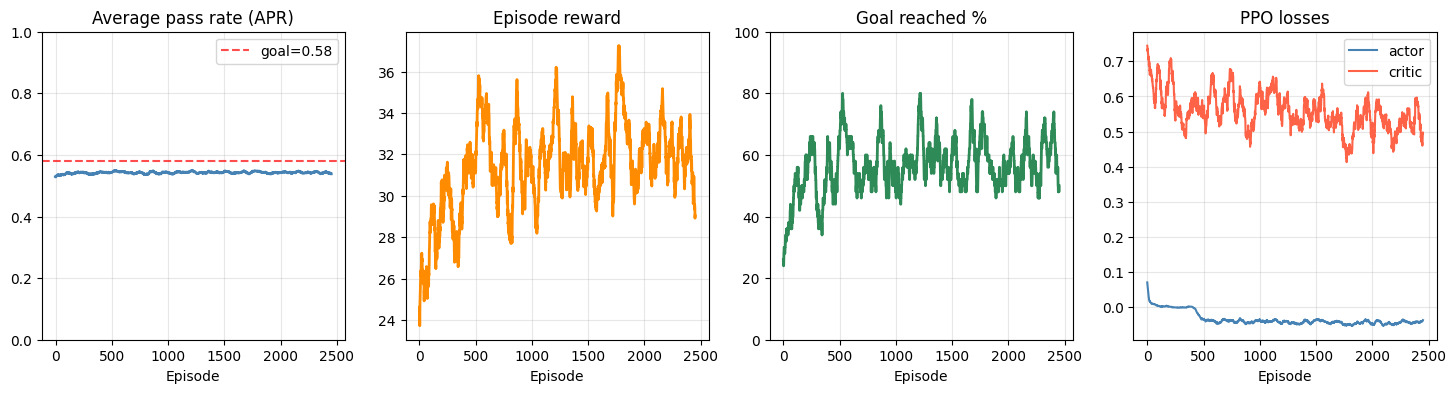

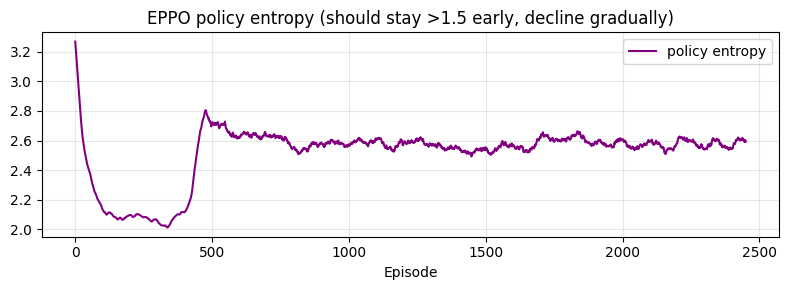

<Figure size 1600x400 with 0 Axes>

Final 300 episodes:
  Mean APR    : 0.542
  Goal rate   : 59.0%
  Mean steps  : 40.2
  Mean reward : +31.66
  Actor loss  : -0.0435
  Critic loss : 0.5178  (healthy: <0.5 after return normalisation)
  Entropy     : 2.5773  (healthy: >1.5)


In [12]:
def smooth(x, w=50):
    if len(x) < w:
        return np.array(x)
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(smooth(metrics['aprs']), color='steelblue', lw=2)
axes[0].axhline(cfg.BETA_APR, color='red', ls='--', alpha=0.7, label=f'goal={cfg.BETA_APR}')
axes[0].set_title('Average pass rate (APR)')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Episode')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(smooth(metrics['rewards']), color='darkorange', lw=2)
axes[1].set_title('Episode reward')
axes[1].set_xlabel('Episode')
axes[1].grid(alpha=0.3)

axes[2].plot(smooth([float(g) for g in metrics['goals']]) * 100, color='seagreen', lw=2)
axes[2].set_title('Goal reached %')
axes[2].set_ylim(0, 100)
axes[2].set_xlabel('Episode')
axes[2].grid(alpha=0.3)

axes[3].plot(smooth(metrics['actor_loss']),  label='actor',  lw=1.5, color='steelblue')
axes[3].plot(smooth(metrics['critic_loss']), label='critic', lw=1.5, color='tomato')
axes[3].set_title('PPO losses')
axes[3].set_xlabel('Episode')
axes[3].legend()
axes[3].grid(alpha=0.3)

# Extra plot: entropy (shows exploration over time)
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.plot(smooth(metrics['entropy']), color='purple', lw=1.5, label='policy entropy')
ax2.set_title('EPPO policy entropy (should stay >1.5 early, decline gradually)')
ax2.set_xlabel('Episode')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/entropy_curve.png', dpi=120)
plt.show()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120)
plt.show()

final_n = -300
print(f'Final {abs(final_n)} episodes:')
print(f'  Mean APR    : {np.mean(metrics["aprs"][final_n:]):.3f}')
print(f'  Goal rate   : {np.mean(metrics["goals"][final_n:])*100:.1f}%')
print(f'  Mean steps  : {np.mean(metrics["steps"][final_n:]):.1f}')
print(f'  Mean reward : {np.mean(metrics["rewards"][final_n:]):+.2f}')
print(f'  Actor loss  : {np.mean(metrics["actor_loss"][final_n:]):.4f}')
print(f'  Critic loss : {np.mean(metrics["critic_loss"][final_n:]):.4f}  (healthy: <0.5 after return normalisation)')
print(f'  Entropy     : {np.mean(metrics["entropy"][final_n:]):.4f}  (healthy: >1.5)')


## 13 · Policy comparison

300 students each through EPPO, Random, and Greedy.

EPPO must beat Random. Matching Greedy in fewer steps counts as a win.



Metric                          EPPO     Random     Greedy
-------------------------------------------------------
Mean APR                       0.547      0.480      0.452
Std APR                        0.020      0.016      0.000
Goal %                           7.0        0.0        0.0
Mean steps                      49.5       50.0       50.0

vs Random: EPPO wins (+0.067)
vs Greedy: EPPO wins


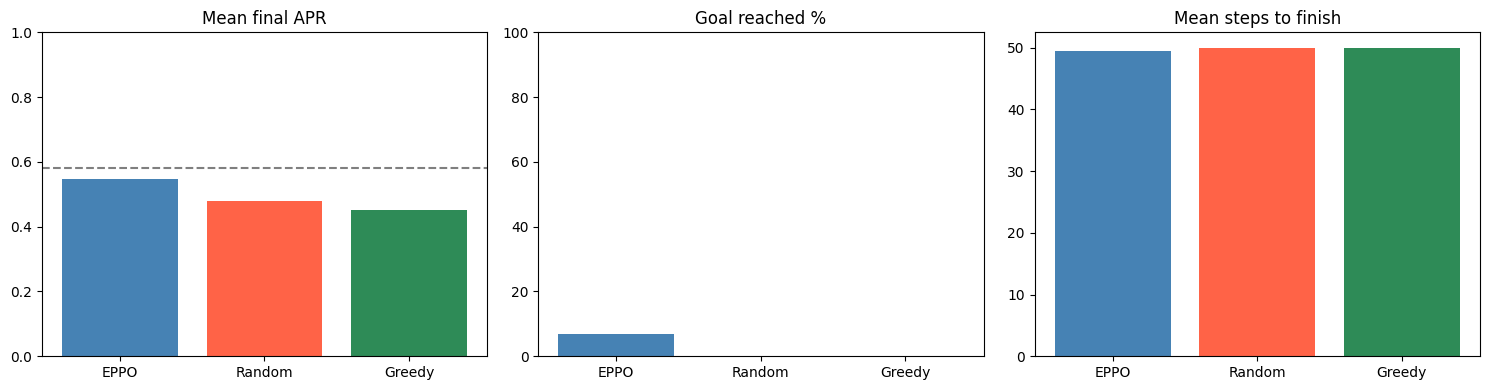

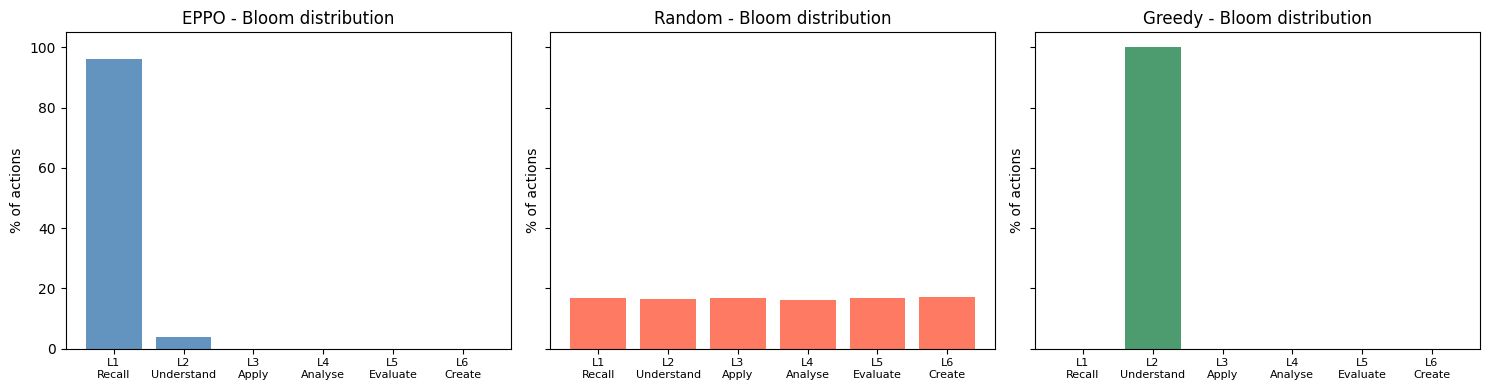

In [13]:
def run_policy_eval(policy_fn, cfg, sim_matrix, rng, n=300):
    aprs, steps, goals = [], [], []
    diff_counts = np.zeros(cfg.BLOOM_LEVELS)
    for _ in range(n):
        t = PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)
        s = RealisticStudent.from_archetype(cfg.CONCEPTS, sim_matrix, rng, cfg, 'mixed')
        covered = set()
        for step in range(cfg.MAX_STEPS):
            mastery = t.get_mastery_matrix()
            apr     = float(np.mean(mastery[:, 0]))
            if apr >= cfg.BETA_APR and ((not cfg.MIN_COVERAGE) or len(covered) >= cfg.N_CONCEPTS):
                break
            ci, lvl = policy_fn(t, mastery, rng, cfg)
            diff_counts[lvl - 1] += 1
            covered.add(ci)
            correct, _, _ = s.answer(ci, lvl)
            t.update_idx(ci, lvl, correct)
            s.learn(ci, lvl, correct)
        final_apr = float(np.mean(t.get_mastery_matrix()[:, 0]))
        aprs.append(final_apr)
        steps.append(step + 1)
        goals.append(final_apr >= cfg.BETA_APR)
    return {
        'mean_apr':   float(np.mean(aprs)),
        'std_apr':    float(np.std(aprs)),
        'goal_rate':  float(np.mean(goals)) * 100,
        'mean_steps': float(np.mean(steps)),
        'diff_dist':  diff_counts / max(diff_counts.sum(), 1),
    }


def eppo_fn(ag):
    def fn(t, mastery, rng, cfg):
        with torch.no_grad():
            a, _, _, _ = ag.select_action(t.get_state_vector(), mastery)
        return a // cfg.BLOOM_LEVELS, a % cfg.BLOOM_LEVELS + 1
    return fn

def random_fn(t, mastery, rng, cfg):
    return int(rng.integers(0, cfg.N_CONCEPTS)), int(rng.integers(1, cfg.BLOOM_LEVELS + 1))

def greedy_fn(t, mastery, rng, cfg):
    ci  = int(np.argmin(mastery[:, 0]))
    cur = max((k for k in range(cfg.BLOOM_LEVELS) if mastery[ci, k] > 0.50), default=0)
    return ci, min(cur + 1, cfg.BLOOM_LEVELS - 1) + 1


eval_rng = np.random.default_rng(77)
agent.eval()

policies = {
    'EPPO':   run_policy_eval(eppo_fn(agent), cfg, sim_matrix, eval_rng),
    'Random': run_policy_eval(random_fn,      cfg, sim_matrix, eval_rng),
    'Greedy': run_policy_eval(greedy_fn,      cfg, sim_matrix, eval_rng),
}

W = 10
print(f'\n{"Metric":<25} {"EPPO":>{W}} {"Random":>{W}} {"Greedy":>{W}}')
print('-' * 55)
for label, key, fmt in [
    ('Mean APR',   'mean_apr',   '.3f'),
    ('Std APR',    'std_apr',    '.3f'),
    ('Goal %',     'goal_rate',  '.1f'),
    ('Mean steps', 'mean_steps', '.1f'),
]:
    row = f'{label:<25}'
    for p in ['EPPO', 'Random', 'Greedy']:
        row += f' {policies[p][key]:>{W}{fmt}}'
    print(row)

e, r, g = policies['EPPO'], policies['Random'], policies['Greedy']
print(f'\nvs Random: {"EPPO wins (+{:.3f})".format(e["mean_apr"]-r["mean_apr"]) if e["mean_apr"]>r["mean_apr"] else "Random wins -- need more training"}')
print(f'vs Greedy: {"EPPO wins" if e["mean_apr"]>g["mean_apr"] or e["mean_steps"]<g["mean_steps"] else "Greedy wins -- EPPO not converged"}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['EPPO', 'Random', 'Greedy']
colors = ['steelblue', 'tomato', 'seagreen']
axes[0].bar(labels, [policies[p]['mean_apr'] for p in labels], color=colors)
axes[0].axhline(cfg.BETA_APR, ls='--', color='black', alpha=0.5)
axes[0].set_title('Mean final APR')
axes[0].set_ylim(0, 1)
axes[1].bar(labels, [policies[p]['goal_rate'] for p in labels], color=colors)
axes[1].set_title('Goal reached %')
axes[1].set_ylim(0, 100)
axes[2].bar(labels, [policies[p]['mean_steps'] for p in labels], color=colors)
axes[2].set_title('Mean steps to finish')
plt.tight_layout()
plt.savefig('/kaggle/working/policy_comparison.png', dpi=120)
plt.show()

bloom_names = ['L1\nRecall','L2\nUnderstand','L3\nApply','L4\nAnalyse','L5\nEvaluate','L6\nCreate']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (p, col) in zip(axes, zip(labels, colors)):
    ax.bar(range(cfg.BLOOM_LEVELS), policies[p]['diff_dist'] * 100, color=col, alpha=0.85)
    ax.set_title(f'{p} - Bloom distribution')
    ax.set_xticks(range(cfg.BLOOM_LEVELS))
    ax.set_xticklabels(bloom_names, fontsize=8)
    ax.set_ylabel('% of actions')
plt.tight_layout()
plt.savefig('/kaggle/working/bloom_distribution.png', dpi=120)
plt.show()


## 14 · Demo session — all 4 student archetypes

Runs one session per archetype (beginner / intermediate / advanced / mixed) with the same random seed so only prior ability differs. This shows whether EPPO adapts its policy to the student's level:

- **Beginner**: mostly L1 Recall, slow APR gain
- **Intermediate**: mix of L1–L3, larger gain, may terminate early
- **Advanced**: higher Bloom levels unlocked early, fast gain
- **Mixed**: variable per-concept ability, tests general policy

The comparison table and plot at the end show side-by-side how the Bloom distribution and APR gain differ across archetypes.


  DEMO: BEGINNER student
  Initial APR: 0.452  |  Final APR: 0.502  |  Gain: +0.050  |  Steps: 50
  Step  Concept                  Level         Mastery   Answer    APR
  ----------------------------------------------------------------
     1  linked list              Recall          0.417  wrong    0.452
     2  TCP IP basics            Recall          0.464  wrong    0.448
     3  memory management        Recall          0.496  CORRECT  0.444
     4  sorting algorithms       Recall          0.479  wrong    0.453
     5  linked list              Recall          0.388  wrong    0.449
     6  recursion                Recall          0.468  wrong    0.447
     7  linked list              Recall          0.370  CORRECT  0.443
     8  TCP IP basics            Understand      0.337  wrong    0.451
     9  sorting algorithms       Recall          0.448  CORRECT  0.451
    10  sorting algorithms       Recall          0.517  CORRECT  0.460
    11  dynamic programming      Recall          0.454

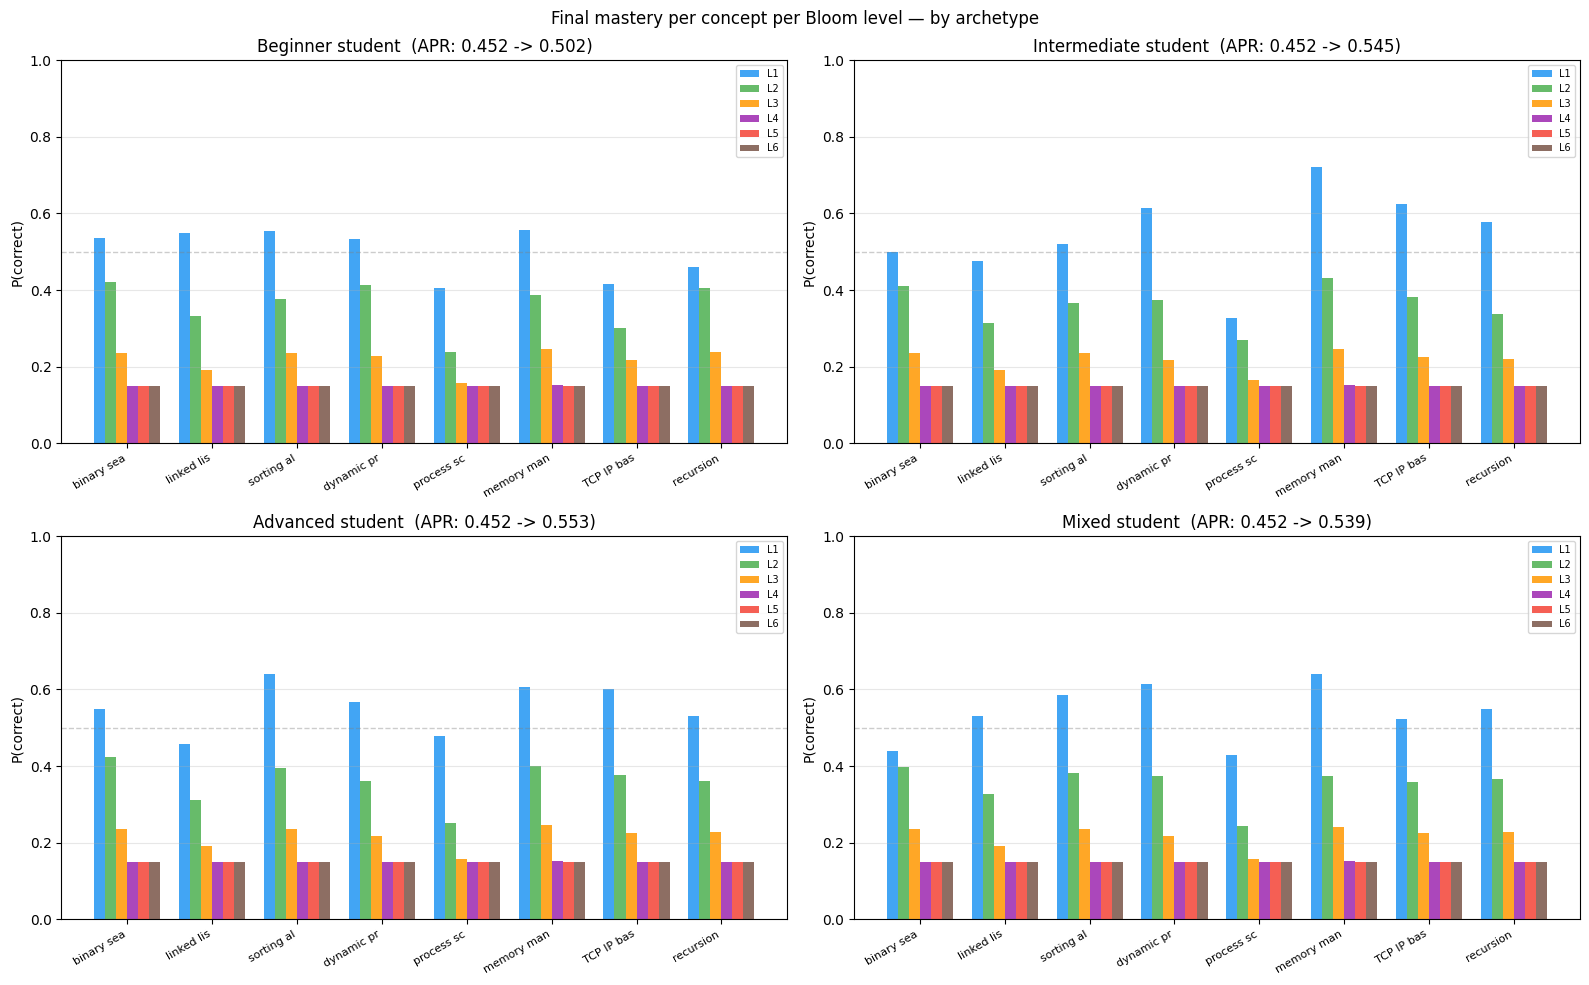

In [14]:
BLOOM_NAMES = ['Recall', 'Understand', 'Apply', 'Analyse', 'Evaluate', 'Create']

def run_demo_session(archetype, seed, cfg, sim_matrix, agent):
    rng_d   = np.random.default_rng(seed)
    tracker = PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)
    student = RealisticStudent.from_archetype(cfg.CONCEPTS, sim_matrix, rng_d, cfg, archetype)
    agent.eval()

    covered      = set()
    bloom_counts = [0] * cfg.BLOOM_LEVELS

    # Same greedy seed as training loop so demo reflects trained conditions
    for _seed in range(cfg.SEED_STEPS):
        _m   = tracker.get_mastery_matrix()
        _ci  = int(rng_d.integers(0, cfg.N_CONCEPTS))
        _cur = max((k for k in range(cfg.BLOOM_LEVELS) if _m[_ci, k] > 0.45), default=0)
        _lvl = min(_cur + 1, cfg.BLOOM_LEVELS - 1) + 1
        _correct, _, _ = student.answer(_ci, _lvl)
        tracker.update_idx(_ci, _lvl, _correct)
        student.learn(_ci, _lvl, _correct)
        covered.add(_ci)

    initial_apr = float(np.mean(tracker.get_mastery_matrix()[:, 0]))
    history = []  # (concept, level_name, mastery, correct, apr)

    for step in range(cfg.MAX_STEPS):
        mastery = tracker.get_mastery_matrix()
        apr     = float(np.mean(mastery[:, 0]))
        improvement = apr - initial_apr
        if (apr >= cfg.BETA_APR or improvement >= 0.10) and len(covered) >= cfg.N_CONCEPTS:
            break
        with torch.no_grad():
            action, _, _, _ = agent.select_action(tracker.get_state_vector(), mastery)
        ci  = action // cfg.BLOOM_LEVELS
        lvl = action  % cfg.BLOOM_LEVELS + 1
        m_val = mastery[ci, lvl - 1]
        correct, true_p, _ = student.answer(ci, lvl)
        tracker.update_idx(ci, lvl, correct)
        student.learn(ci, lvl, correct)
        covered.add(ci)
        bloom_counts[lvl - 1] += 1
        history.append((cfg.CONCEPTS[ci], BLOOM_NAMES[lvl-1], m_val, correct, apr))

    final_mastery = tracker.get_mastery_matrix()
    final_apr     = float(np.mean(final_mastery[:, 0]))
    return history, final_mastery, final_apr, initial_apr, bloom_counts


def print_demo(archetype, history, final_mastery, final_apr, initial_apr, bloom_counts, cfg):
    W = 72
    arch_label = archetype.upper()
    print('=' * W)
    print(f'  DEMO: {arch_label} student')
    print(f'  Initial APR: {initial_apr:.3f}  |  Final APR: {final_apr:.3f}  '
          f'|  Gain: {final_apr - initial_apr:+.3f}  |  Steps: {len(history)}')
    print('=' * W)
    print(f'  {"Step":>4}  {"Concept":<24} {"Level":<12} {"Mastery":>8} {"Answer":>8} {"APR":>6}')
    print('  ' + '-' * 64)
    for i, (concept, level_name, m_val, correct, apr) in enumerate(history):
        ans = 'CORRECT' if correct else 'wrong  '
        print(f'  {i+1:>4}  {concept:<24} {level_name:<12} {m_val:>8.3f} {ans:>8} {apr:>6.3f}')
    print()
    print(f'  {"Concept":<24} {"L1":>5} {"L2":>5} {"L3":>5} {"L4":>5} {"L5":>5} {"L6":>5}  Progress')
    print('  ' + '-' * 70)
    for i, c in enumerate(cfg.CONCEPTS):
        vals = final_mastery[i]
        bar  = chr(9608) * int(vals[0] * 10) + chr(9617) * (10 - int(vals[0] * 10))
        print(f'  {c:<24} ' + ' '.join(f'{v:>5.2f}' for v in vals) + f'  {bar}')
    print()
    total = sum(bloom_counts)
    print('  Bloom level usage:')
    for k, (name, count) in enumerate(zip(BLOOM_NAMES, bloom_counts)):
        pct = count / max(total, 1) * 100
        bar = chr(9608) * int(pct / 5)
        print(f'    L{k+1} {name:<12} {count:>3} actions ({pct:4.1f}%)  {bar}')
    print()


# Run all 4 archetypes — same seed so only ability differs
DEMO_SEED = 42
archetypes = ['beginner', 'intermediate', 'advanced', 'mixed']
demo_results = {}

for arch in archetypes:
    hist, fm, fapr, iapr, bc = run_demo_session(arch, DEMO_SEED, cfg, sim_matrix, agent)
    demo_results[arch] = (hist, fm, fapr, iapr, bc)
    print_demo(arch, hist, fm, fapr, iapr, bc, cfg)


# ── Side-by-side comparison ──────────────────────────────────────────────
print('=' * 72)
print('  ARCHETYPE COMPARISON')
print('=' * 72)
print(f'  {"Archetype":<14} {"Init APR":>9} {"Final APR":>10} {"Gain":>7} '
      f'{"Steps":>6} {"L1%":>5} {"L2%":>5} {"L3%":>5} {"L4+%":>6}')
print('  ' + '-' * 68)
for arch in archetypes:
    hist, fm, fapr, iapr, bc = demo_results[arch]
    total = sum(bc)
    l1p = bc[0]/max(total,1)*100
    l2p = bc[1]/max(total,1)*100
    l3p = bc[2]/max(total,1)*100
    l4p = sum(bc[3:])/max(total,1)*100
    print(f'  {arch:<14} {iapr:>9.3f} {fapr:>10.3f} {fapr-iapr:>+7.3f} '
          f'{len(hist):>6} {l1p:>5.1f} {l2p:>5.1f} {l3p:>5.1f} {l4p:>6.1f}')
print()
print('  What to look for:')
print('    Beginner    -> mostly L1, small APR gain, all 50 steps used')
print('    Intermediate-> mix of L1/L2/L3, larger APR gain, may terminate early')
print('    Advanced    -> higher Bloom levels unlocked, fast APR gain')
print('    Mixed       -> variable, depends on per-concept ability draw')


# ── Per-concept mastery comparison plot ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors_bloom = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#795548']

for ax, arch in zip(axes, archetypes):
    _, fm, fapr, iapr, bc = demo_results[arch]
    x = np.arange(cfg.N_CONCEPTS)
    width = 0.13
    for k in range(cfg.BLOOM_LEVELS):
        ax.bar(x + k * width, fm[:, k], width, label=f'L{k+1}', color=colors_bloom[k], alpha=0.85)
    ax.set_title(f'{arch.capitalize()} student  (APR: {iapr:.3f} -> {fapr:.3f})')
    ax.set_xticks(x + width * 2.5)
    ax.set_xticklabels([c[:10] for c in cfg.CONCEPTS], rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('P(correct)')
    ax.legend(loc='upper right', fontsize=7)
    ax.axhline(0.50, color='gray', ls='--', alpha=0.4, lw=1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Final mastery per concept per Bloom level — by archetype', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/demo_archetype_comparison.png', dpi=120)
plt.show()


## 15 · Readiness checklist

In [15]:
print('\n' + '=' * 60)
print('  READINESS CHECKLIST')
print('=' * 60)

sl        = slice(-200, None)
mean_apr  = np.mean(metrics['aprs'][sl])
goal_rate = np.mean(metrics['goals'][sl]) * 100
mean_steps= np.mean(metrics['steps'][sl])
ece       = val_results.get('ece', 1.0)
auc       = val_results.get('auc', 0.0)

e = policies['EPPO']
r = policies['Random']
g = policies['Greedy']
beats_rnd = e['mean_apr'] > r['mean_apr']
beats_grd = e['mean_apr'] > g['mean_apr'] or e['mean_steps'] < g['mean_steps']

checks = [
    ('PFA ECE < 0.10',             ece < 0.10,          f'ECE={ece:.4f}'),
    ('PFA AUC > 0.65',             auc > 0.65,          f'AUC={auc:.3f}'),
    ('Final APR > 0.60',           mean_apr > 0.60,     f'APR={mean_apr:.3f}'),
    ('Goal rate > 40%',            goal_rate > 40,      f'{goal_rate:.1f}%'),
    ('Avg steps 10-45',            10 < mean_steps < 45, f'{mean_steps:.1f} steps'),
    ('EPPO beats Random',          beats_rnd,           f'EPPO={e["mean_apr"]:.3f} vs Rnd={r["mean_apr"]:.3f}'),
    ('EPPO competitive w/ Greedy', beats_grd,           f'EPPO={e["mean_apr"]:.3f} vs Grd={g["mean_apr"]:.3f}'),
]

all_pass = True
for label, ok, detail in checks:
    print(f'  [{"PASS" if ok else "FAIL"}] {label:<35} {detail}')
    if not ok:
        all_pass = False

print()
if all_pass:
    print('  All checks passed - ready to scale to full concept set.')
    print('  Next steps:')
    print('    1. Replace CONCEPTS list with domain-extracted concepts')
    print('    2. Connect (concept, bloom_level) output to question generator')
    print('    3. Collect real student interactions and retrain')
else:
    print('  Some checks failed:')
    if ece >= 0.10:
        print('    ECE high -> lower GAMMA_LEVEL or shift BETA_LEVEL down further')
    if goal_rate <= 40:
        print('    Goal rate low -> increase N_EPISODES or lower BETA_APR')
    if mean_steps >= 45:
        print('    Sessions too long -> check MIN_COVERAGE or MAX_SAME_CONCEPT')
    if not beats_rnd:
        print('    EPPO not beating random -> increase N_EPISODES to 3000 or raise LR_ACTOR to 5e-4')
print('=' * 60)



  READINESS CHECKLIST
  [PASS] PFA ECE < 0.10                      ECE=0.0637
  [FAIL] PFA AUC > 0.65                      AUC=0.586
  [FAIL] Final APR > 0.60                    APR=0.542
  [PASS] Goal rate > 40%                     61.0%
  [PASS] Avg steps 10-45                     39.8 steps
  [PASS] EPPO beats Random                   EPPO=0.547 vs Rnd=0.480
  [PASS] EPPO competitive w/ Greedy          EPPO=0.547 vs Grd=0.452

  Some checks failed:
